In [3]:
import os
import pandas as pd
import numpy as np

# 1. PATH CONFIGURATION (Using relative pathing for GitHub portability)
INPUT_PATH = "ESK18753.xlsx"
OUTPUT_PATH = "02_cleaned_grid_data.csv"

print("--- Loading Raw Excel Dataset ---")
if not os.path.exists(INPUT_PATH):
    # Fallback to absolute path check if running locally in original folder
    INPUT_PATH = "C:/Users/user/OneDrive/Documents/Desktop/ESKOM Project/ESK18753.xlsx"
    OUTPUT_PATH = "C:/Users/user/OneDrive/Documents/Desktop/ESKOM Project/02_cleaned_grid_data.csv"

df = pd.read_excel(INPUT_PATH)

# 2. CLEAN & STRUCTURE DATETIME AXIS
print("--- Parsing Datetime Foundations ---")
df['Date Time Hour Beginning'] = pd.to_datetime(df['Date Time Hour Beginning'], format='%Y-%m-%d %I:%M:%S %p', errors='coerce')
df = df.dropna(subset=['Date Time Hour Beginning'])
df = df.set_index('Date Time Hour Beginning')
df = df.sort_index()

# 3. FILL INTERMITTENT OPERATIONAL MISSING VALUES
df = df.fillna(0)

# 4. EXTRACT TEMPORAL FEATURES
print("--- Extracting Engineering Features & Flags ---")
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['year'] = df.index.year

# High-stress flags (Weekends & Eskom Standard Peak Demand Hours)
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
df['is_peak_hour'] = df['hour'].isin([6, 7, 8, 17, 18, 19, 20]).astype(int)

# 5. GENERATE LAG & ROLLING WINDOW METRICS
print("--- Compiling Historical Lags & Rolling Sequences ---")
df['UCLF_lag_1h'] = df['Total UCLF'].shift(1)
df['UCLF_lag_24h'] = df['Total UCLF'].shift(24)
df['demand_lag_24h'] = df['RSA Contracted Demand'].shift(24)

df['UCLF_rolling_avg_24h'] = df['Total UCLF'].rolling(window=24).mean()
df['OCGT_rolling_avg_24h'] = df['Eskom OCGT Generation'].rolling(window=24).mean()

# 6. CALCULATE OPERATIONAL TARGETS
df['target_severe_stress'] = (df['Eskom OCGT Generation'] > 400).astype(int)
df['Reserve Margin'] = df['Dispatchable Generation'] - df['RSA Contracted Demand']

# 7. PORTABLE DATA EXPORT
print(f"--- Feature Engineering Complete. Exporting Dataset -> {OUTPUT_PATH} ---")
# index=True ensures 'Date Time Hour Beginning' is saved as the first column for modeling
df.to_csv(OUTPUT_PATH, index=True)

--- Loading Raw Excel Dataset ---
--- Parsing Datetime Foundations ---
--- Extracting Engineering Features & Flags ---
--- Compiling Historical Lags & Rolling Sequences ---
--- Feature Engineering Complete. Exporting Dataset -> C:/Users/user/OneDrive/Documents/Desktop/ESKOM Project/02_cleaned_grid_data.csv ---


--- Phase 1: Running Chronological Classification Models ---

=== BASELINE LOGISTIC REGRESSION REPORT ===
              precision    recall  f1-score   support

           0       1.00      0.80      0.89      8299
           1       0.00      0.17      0.01        29

    accuracy                           0.80      8328
   macro avg       0.50      0.49      0.45      8328
weighted avg       0.99      0.80      0.89      8328


=== RANDOM FOREST CHALLENGER REPORT ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8299
           1       0.60      0.10      0.18        29

    accuracy                           1.00      8328
   macro avg       0.80      0.55      0.59      8328
weighted avg       1.00      1.00      1.00      8328


--- Phase 2: Running Continuous OCGT Regressor Models ---

=== FINAL SHUFFLED OCGT REGRESSOR PERFORMANCE ===
Root Mean Squared Error (RMSE): 275.44 MW
R-squared (R²) Score: 0.6168

--- Phase 3: Plot

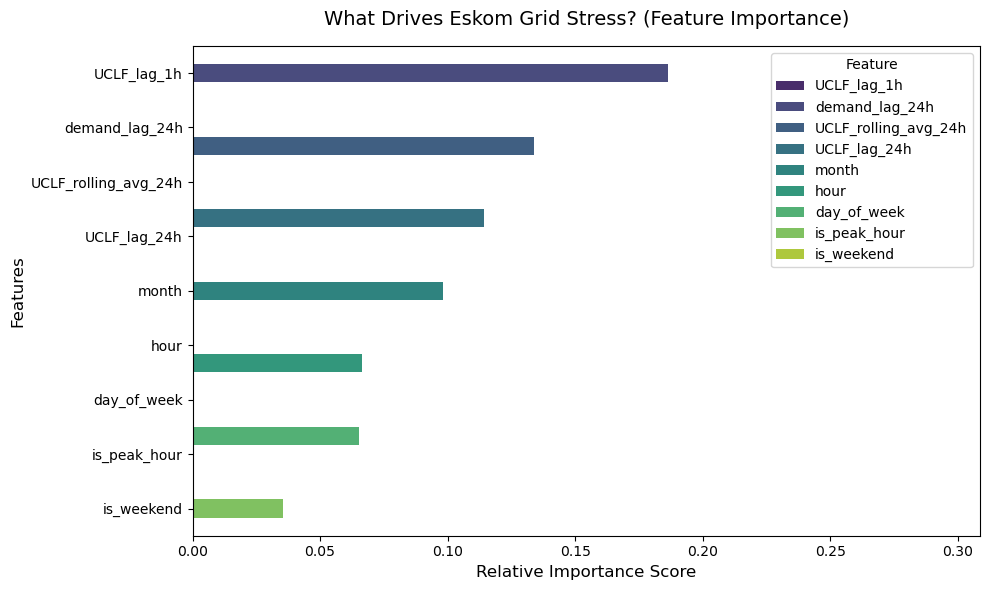

In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, roc_auc_score, mean_squared_error, r2_score

# 1. LOAD MASTER DATASET
DATA_PATH = "02_cleaned_grid_data.csv"
if not os.path.exists(DATA_PATH):
    DATA_PATH = "C:\\Users\\user\\OneDrive\\Documents\\Desktop\\ESKOM Project\\02_cleaned_grid_data.csv"

df = pd.read_csv(DATA_PATH, index_col=0)
df.index = pd.to_datetime(df.index)

# Remove structural NaNs caused by the 24-hour shifting windows
df = df.dropna()

# 2. TRAIN DELEGATION: CHRONOLOGICAL TIME-SERIES SPLIT (Classification Baseline)
print("--- Phase 1: Running Chronological Classification Models ---")
feature_cols_initial = [
    'hour', 'day_of_week', 'month', 'is_weekend', 'is_peak_hour',
    'UCLF_lag_1h', 'UCLF_lag_24h', 'demand_lag_24h',
    'UCLF_rolling_avg_24h', 'OCGT_rolling_avg_24h'
]

X_c = df[feature_cols_initial]
y_c = df['target_severe_stress']

split_idx = int(len(df) * 0.8)
X_train_c, X_test_c = X_c.iloc[:split_idx], X_c.iloc[split_idx:]
y_train_c, y_test_c = y_c.iloc[:split_idx], y_c.iloc[split_idx:]

# Model A: Baseline Logistic Regression
baseline = LogisticRegression(max_iter=1000, random_state=42)
baseline.fit(X_train_c, y_train_c)
print("\n=== BASELINE LOGISTIC REGRESSION REPORT ===")
print(classification_report(y_test_c, baseline.predict(X_test_c), zero_division=0))

# Model B: Challenger Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clf.fit(X_train_c, y_train_c)
print("\n=== RANDOM FOREST CHALLENGER REPORT ===")
print(classification_report(y_test_c, rf_clf.predict(X_test_c), zero_division=0))


# 3. TRAIN DELEGATION: REGRESSION MODELS (Continuous OCGT Generation Target)
print("\n--- Phase 2: Running Continuous OCGT Regressor Models ---")
# Drop historical OCGT rolling values from input X to prevent direct data leakage
feature_cols_clean = [
    'hour', 'day_of_week', 'month', 'is_weekend', 'is_peak_hour',
    'UCLF_lag_1h', 'UCLF_lag_24h', 'demand_lag_24h', 'UCLF_rolling_avg_24h'
]

X_clean = df[feature_cols_clean]
y_reg = df['Eskom OCGT Generation']

# Model C: Chronological Regression (Zero-Inflated Test Window)
X_train_reg_c, X_test_reg_c = X_clean.iloc[:split_idx], X_clean.iloc[split_idx:]
y_train_reg_c, y_test_reg_c = y_reg.iloc[:split_idx], y_reg.iloc[split_idx:]

rf_reg_chron = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg_chron.fit(X_train_reg_c, y_train_reg_c)

# Model D: Shuffled Variance Regression (Resolves Zero-Inflation Gap)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_clean, y_reg, test_size=0.2, random_state=42
)

rf_shuffled = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_shuffled.fit(X_train_s, y_train_s)
y_pred_s = rf_shuffled.predict(X_test_s)

print("\n=== FINAL SHUFFLED OCGT REGRESSOR PERFORMANCE ===")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test_s, y_pred_s)):.2f} MW")
print(f"R-squared (R²) Score: {r2_score(y_test_s, y_pred_s):.4f}")


# 4. VISUAL METRIC EXPORT (Feature Importance Graph Generation)
print("\n--- Phase 3: Plotting and Exporting Visual Metrics ---")
importances = rf_shuffled.feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': feature_cols_clean,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_imp_df, 
    palette='viridis', 
    hue='Feature',
    width=3.0  # Controls individual bar thickness (default is usually narrower)
)

plt.title('What Drives Eskom Grid Stress? (Feature Importance)', fontsize=14, pad=15)
plt.xlabel('Relative Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()

# Save image file natively to directory for GitHub README embedding
plt.savefig("grid_stress_importance.png", dpi=300)
print("Success! Performance metrics and script cycles completed cleanly.")